<a href="https://colab.research.google.com/github/Shaikh-Uzair-Ahmed/1BM23CS307/blob/ML/1BM23CS307_Lab5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/iris (1).csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

First 5 rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [2]:
X = df.drop('species', axis=1)
y = df['species']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of X:")
print(X.head())
print("\nFirst 5 values of y:")
print(y.head())

Features (X) shape: (150, 4)
Target (y) shape: (150,)
First 5 rows of X:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

First 5 values of y:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


**Reasoning**:
Split the dataset into training and testing sets using an 80/20 ratio, ensuring stratification to maintain the proportion of classes, and setting a random_state for reproducibility, as per instruction 3.



In [3]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


**Reasoning**:
Initialize a KNeighborsClassifier model with n_neighbors=5, as per instruction 4, which is a common default value for KNN.



In [4]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier model with n_neighbors=5
knn_model = KNeighborsClassifier(n_neighbors=5)

print("KNN model initialized:")
print(knn_model)

KNN model initialized:
KNeighborsClassifier()


**Reasoning**:
Train the initialized KNN model using the training data (X_train and y_train) to learn the relationships between features and the target variable, as per instruction 5.



In [5]:
knn_model.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


**Reasoning**:
Make predictions on the test set (X_test) using the trained `knn_model` to evaluate its performance, as per instruction 6.



In [6]:
y_pred = knn_model.predict(X_test)

print("First 5 predictions on the test set:")
print(y_pred[:5])
print("Length of predictions:", len(y_pred))

First 5 predictions on the test set:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa']
Length of predictions: 30


**Reasoning**:
Calculate the accuracy score of the model by comparing the predicted values (`y_pred`) with the actual test values (`y_test`), as per instruction 7.



In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 1.0000


**Reasoning**:
Generate and display the confusion matrix to evaluate the performance of the classification model, as per instruction 8.



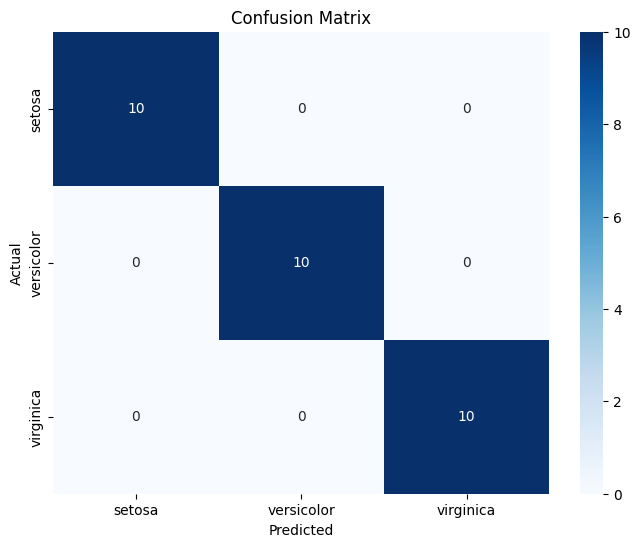

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn_model.classes_, yticklabels=knn_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix:\n", cm)

**Reasoning**:
Generate and display the classification report, which provides detailed metrics such as precision, recall, and f1-score for each class, as per instruction 9.



In [9]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [10]:
import numpy as np

def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points."""
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

print("Euclidean distance function defined.")

Euclidean distance function defined.


#### **Reasoning**:
Define the `predict_one` function, which will take a single test data point, the training data, and the number of neighbors `k` to predict its class based on the majority vote of its `k` nearest neighbors, as specified in instruction 2.

**Reasoning**:
Implement the `predict_one` function as described, which calculates the Euclidean distance from a test point to all training points, sorts them, selects the top `k` neighbors, and returns the most frequent class among them.



In [11]:
from collections import Counter

def predict_one(test_point, X_train, y_train, k):
    """Predicts the class of a single test point using KNN."""
    distances = []
    for i, train_point in enumerate(X_train.values):
        dist = euclidean_distance(test_point, train_point)
        distances.append((dist, y_train.iloc[i]))

    distances.sort(key=lambda x: x[0])

    k_nearest_neighbors = distances[:k]
    k_nearest_labels = [label for dist, label in k_nearest_neighbors]

    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

print("predict_one function defined.")

predict_one function defined.


#### **Reasoning**:
Define a main prediction function, for example `custom_knn_predict`, that takes `X_test`, `X_train`, `y_train`, and `k` as input. This function should iterate through each data point in `X_test` and call the `predict_one` function for each, collecting all individual predictions into a list, as per instruction 3.

**Reasoning**:
Implement the `custom_knn_predict` function to iterate through the test set and use the `predict_one` function to generate predictions for all test points.



In [12]:
def custom_knn_predict(X_test, X_train, y_train, k):
    """Makes predictions for the entire test set using the custom KNN algorithm."""
    predictions = []
    for i, test_point in enumerate(X_test.values):
        # Use .iloc[i] to get the specific index if X_test is a DataFrame
        prediction = predict_one(test_point, X_train, y_train, k)
        predictions.append(prediction)
    return predictions

print("custom_knn_predict function defined.")

custom_knn_predict function defined.


In [13]:
k = 5
y_pred_custom = custom_knn_predict(X_test, X_train, y_train, k)

print(f"First 5 custom KNN predictions (k={k}):")
print(y_pred_custom[:5])
print(f"Length of custom predictions: {len(y_pred_custom)}")

First 5 custom KNN predictions (k=5):
['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa']
Length of custom predictions: 30


In [14]:
from sklearn.metrics import accuracy_score

accuracy_custom = accuracy_score(y_test, y_pred_custom)

print(f"Custom KNN Model Accuracy: {accuracy_custom:.4f}")

Custom KNN Model Accuracy: 1.0000


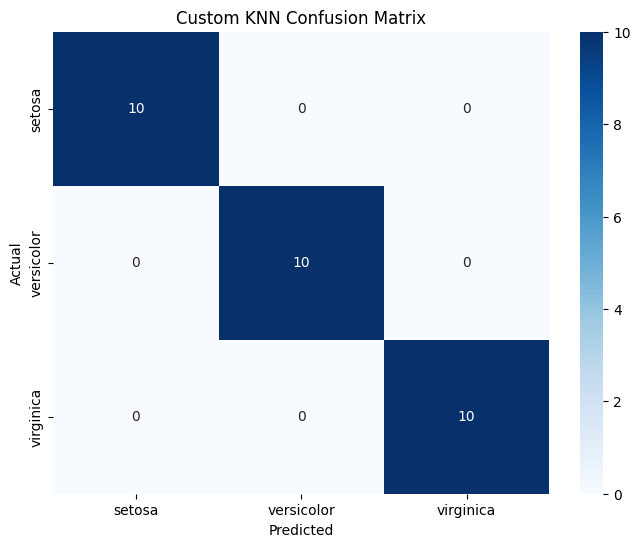

Custom KNN Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique class labels for consistent plotting
class_labels = sorted(list(set(y_test).union(set(y_pred_custom))))

# Generate the confusion matrix
cm_custom = confusion_matrix(y_test, y_pred_custom, labels=class_labels)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Custom KNN Confusion Matrix')
plt.show()

print("Custom KNN Confusion Matrix:\n", cm_custom)

In [16]:
from sklearn.metrics import classification_report

# Generate the classification report
report_custom = classification_report(y_test, y_pred_custom)

print("Custom KNN Classification Report:")
print(report_custom)

Custom KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [17]:
import pandas as pd

# Load the dataset
df_diabetes = pd.read_csv('/content/diabetes.csv')

# Display the first 5 rows
print("First 5 rows of the diabetes dataset:")
print(df_diabetes.head())

# Display the column names
print("\nColumn names of the diabetes dataset:")
print(df_diabetes.columns.tolist())

First 5 rows of the diabetes dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Column names of the diabetes dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [18]:
X_diabetes = df_diabetes.drop('Outcome', axis=1)
y_diabetes = df_diabetes['Outcome']

print("Features (X_diabetes) shape:", X_diabetes.shape)
print("Target (y_diabetes) shape:", y_diabetes.shape)
print("\nFirst 5 rows of X_diabetes:")
print(X_diabetes.head())
print("\nFirst 5 values of y_diabetes:")
print(y_diabetes.head())

Features (X_diabetes) shape: (768, 8)
Target (y_diabetes) shape: (768,)

First 5 rows of X_diabetes:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

First 5 values of y_diabetes:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to X_diabetes and transform it
X_scaled_diabetes = scaler.fit_transform(X_diabetes)

# Convert the scaled array back to a DataFrame for easier viewing
X_scaled_diabetes = pd.DataFrame(X_scaled_diabetes, columns=X_diabetes.columns)

print("First 5 rows of scaled features (X_scaled_diabetes):")
print(X_scaled_diabetes.head())

First 5 rows of scaled features (X_scaled_diabetes):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.848324       0.149641       0.907270 -0.692891  0.204013   
1    -0.844885 -1.123396      -0.160546       0.530902 -0.692891 -0.684422   
2     1.233880  1.943724      -0.263941      -1.288212 -0.692891 -1.103255   
3    -0.844885 -0.998208      -0.160546       0.154533  0.123302 -0.494043   
4    -1.141852  0.504055      -1.504687       0.907270  0.765836  1.409746   

   DiabetesPedigreeFunction       Age  
0                  0.468492  1.425995  
1                 -0.365061 -0.190672  
2                  0.604397 -0.105584  
3                 -0.920763 -1.041549  
4                  5.484909 -0.020496  


In [20]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
X_train_diabetes_scaled, X_test_diabetes_scaled, y_train_diabetes, y_test_diabetes = train_test_split(
    X_scaled_diabetes, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes
)

print("X_train_diabetes_scaled shape:", X_train_diabetes_scaled.shape)
print("X_test_diabetes_scaled shape:", X_test_diabetes_scaled.shape)
print("y_train_diabetes shape:", y_train_diabetes.shape)
print("y_test_diabetes shape:", y_test_diabetes.shape)

X_train_diabetes_scaled shape: (614, 8)
X_test_diabetes_scaled shape: (154, 8)
y_train_diabetes shape: (614,)
y_test_diabetes shape: (154,)


**Reasoning**:
Initialize a KNeighborsClassifier model with n_neighbors=5, as per instruction 5.



In [21]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier model with n_neighbors=5
knn_model_diabetes = KNeighborsClassifier(n_neighbors=5)

print("KNN model for diabetes dataset initialized:")
print(knn_model_diabetes)

KNN model for diabetes dataset initialized:
KNeighborsClassifier()


In [22]:
knn_model_diabetes.fit(X_train_diabetes_scaled, y_train_diabetes)

print("KNN model for diabetes dataset trained successfully.")

KNN model for diabetes dataset trained successfully.


In [23]:
y_pred_diabetes = knn_model_diabetes.predict(X_test_diabetes_scaled)

print("First 5 predictions on the diabetes test set:")
print(y_pred_diabetes[:5])
print(f"Length of diabetes predictions: {len(y_pred_diabetes)}")

First 5 predictions on the diabetes test set:
[1 0 0 0 0]
Length of diabetes predictions: 154


In [24]:
from sklearn.metrics import accuracy_score

accuracy_diabetes = accuracy_score(y_test_diabetes, y_pred_diabetes)

print(f"Diabetes KNN Model Accuracy: {accuracy_diabetes:.4f}")

Diabetes KNN Model Accuracy: 0.7078


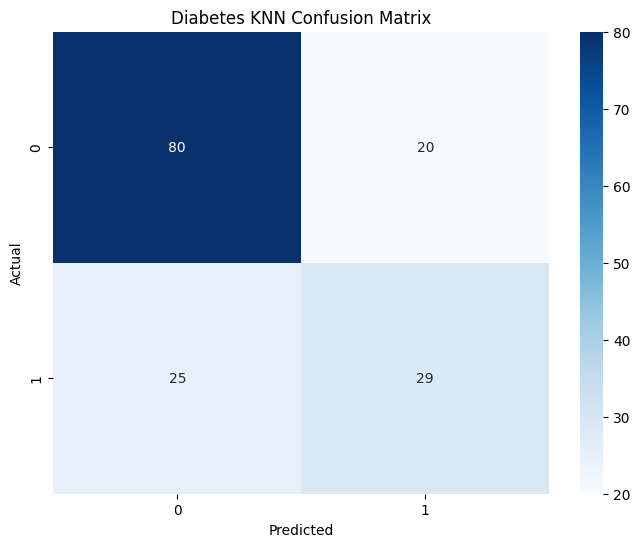

Diabetes KNN Confusion Matrix:
 [[80 20]
 [25 29]]


In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique class labels for consistent plotting
class_labels_diabetes = sorted(list(set(y_test_diabetes).union(set(y_pred_diabetes))))

# Generate the confusion matrix
cm_diabetes = confusion_matrix(y_test_diabetes, y_pred_diabetes, labels=class_labels_diabetes)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_diabetes, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_diabetes, yticklabels=class_labels_diabetes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Diabetes KNN Confusion Matrix')
plt.show()

print("Diabetes KNN Confusion Matrix:\n", cm_diabetes)

In [26]:
from sklearn.metrics import classification_report

# Generate the classification report
report_diabetes = classification_report(y_test_diabetes, y_pred_diabetes)

print("Diabetes KNN Classification Report:")
print(report_diabetes)

Diabetes KNN Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       100
           1       0.59      0.54      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.70       154



In [27]:
k_diabetes = 5
y_pred_diabetes_custom = custom_knn_predict(X_test_diabetes_scaled, X_train_diabetes_scaled, y_train_diabetes, k_diabetes)

print(f"First 5 custom KNN predictions for diabetes (k={k_diabetes}):")
print(y_pred_diabetes_custom[:5])
print(f"Length of custom diabetes predictions: {len(y_pred_diabetes_custom)}")

First 5 custom KNN predictions for diabetes (k=5):
[np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Length of custom diabetes predictions: 154


In [28]:
from sklearn.metrics import accuracy_score

accuracy_diabetes_custom = accuracy_score(y_test_diabetes, y_pred_diabetes_custom)

print(f"Custom KNN Model Accuracy for Diabetes: {accuracy_diabetes_custom:.4f}")

Custom KNN Model Accuracy for Diabetes: 0.7078


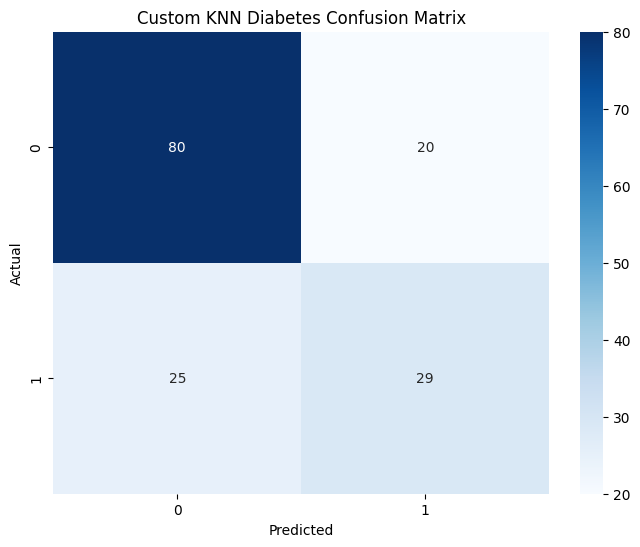

Custom KNN Diabetes Confusion Matrix:
 [[80 20]
 [25 29]]


In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique class labels for consistent plotting
class_labels_diabetes_custom = sorted(list(set(y_test_diabetes).union(set(y_pred_diabetes_custom))))

# Generate the confusion matrix
cm_diabetes_custom = confusion_matrix(y_test_diabetes, y_pred_diabetes_custom, labels=class_labels_diabetes_custom)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_diabetes_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_diabetes_custom, yticklabels=class_labels_diabetes_custom)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Custom KNN Diabetes Confusion Matrix')
plt.show()

print("Custom KNN Diabetes Confusion Matrix:\n", cm_diabetes_custom)

In [30]:
from sklearn.metrics import classification_report

# Generate the classification report
report_diabetes_custom = classification_report(y_test_diabetes, y_pred_diabetes_custom)

print("Custom KNN Diabetes Classification Report:")
print(report_diabetes_custom)

Custom KNN Diabetes Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       100
           1       0.59      0.54      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.70       154



In [31]:
import pandas as pd

# Load the dataset
df_heart = pd.read_csv('/content/heart.csv')

# Display the first 5 rows
print("First 5 rows of the heart dataset:")
print(df_heart.head())

# Display the column names
print("\nColumn names of the heart dataset:")
print(df_heart.columns.tolist())

First 5 rows of the heart dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Column names of the heart dataset:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [32]:
X_heart = df_heart.drop('target', axis=1)
y_heart = df_heart['target']

print("Features (X_heart) shape:", X_heart.shape)
print("Target (y_heart) shape:", y_heart.shape)
print("\nFirst 5 rows of X_heart:")
print(X_heart.head())
print("\nFirst 5 values of y_heart:")
print(y_heart.head())

Features (X_heart) shape: (303, 13)
Target (y_heart) shape: (303,)

First 5 rows of X_heart:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  
0   0     1  
1   0     2  
2   0     2  
3   0     2  
4   0     2  

First 5 values of y_heart:
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

print("X_train_heart shape:", X_train_heart.shape)
print("X_test_heart shape:", X_test_heart.shape)
print("y_train_heart shape:", y_train_heart.shape)
print("y_test_heart shape:", y_test_heart.shape)

X_train_heart shape: (242, 13)
X_test_heart shape: (61, 13)
y_train_heart shape: (242,)
y_test_heart shape: (61,)


In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(1, 21))
accuracies_heart = []

for k in k_values:
    # Initialize the KNeighborsClassifier model with the current k
    knn_model_heart = KNeighborsClassifier(n_neighbors=k)

    # Train the model using the training data
    knn_model_heart.fit(X_train_heart, y_train_heart)

    # Make predictions on the test data
    y_pred_heart = knn_model_heart.predict(X_test_heart)

    # Calculate the accuracy of the model on the test data
    accuracy = accuracy_score(y_test_heart, y_pred_heart)
    accuracies_heart.append(accuracy)

print("Accuracies for different k values:")
for k, acc in zip(k_values, accuracies_heart):
    print(f"k={k}: {acc:.4f}")

Accuracies for different k values:
k=1: 0.5410
k=2: 0.5410
k=3: 0.6230
k=4: 0.5902
k=5: 0.5902
k=6: 0.5738
k=7: 0.6393
k=8: 0.5902
k=9: 0.5902
k=10: 0.6066
k=11: 0.6066
k=12: 0.6066
k=13: 0.6230
k=14: 0.6066
k=15: 0.6393
k=16: 0.6721
k=17: 0.6721
k=18: 0.6721
k=19: 0.6721
k=20: 0.6721


In [35]:
optimal_k_heart = k_values[accuracies_heart.index(max(accuracies_heart))]

print(f"Optimal k for Heart Dataset: {optimal_k_heart}")

Optimal k for Heart Dataset: 16


In [36]:
knn_model_heart_optimal = KNeighborsClassifier(n_neighbors=optimal_k_heart)

print("KNN model for heart dataset initialized with optimal k:")
print(knn_model_heart_optimal)

KNN model for heart dataset initialized with optimal k:
KNeighborsClassifier(n_neighbors=16)


In [37]:
knn_model_heart_optimal.fit(X_train_heart, y_train_heart)

print("Optimal KNN model for heart dataset trained successfully.")

Optimal KNN model for heart dataset trained successfully.


In [38]:
y_pred_heart_optimal = knn_model_heart_optimal.predict(X_test_heart)

print("First 5 predictions on the heart test set with optimal k:")
print(y_pred_heart_optimal[:5])
print(f"Length of optimal heart predictions: {len(y_pred_heart_optimal)}")

First 5 predictions on the heart test set with optimal k:
[0 1 0 1 1]
Length of optimal heart predictions: 61


In [39]:
from sklearn.metrics import accuracy_score

accuracy_heart_optimal = accuracy_score(y_test_heart, y_pred_heart_optimal)

print(f"Optimal KNN Model Accuracy for Heart Dataset: {accuracy_heart_optimal:.4f}")

Optimal KNN Model Accuracy for Heart Dataset: 0.6721


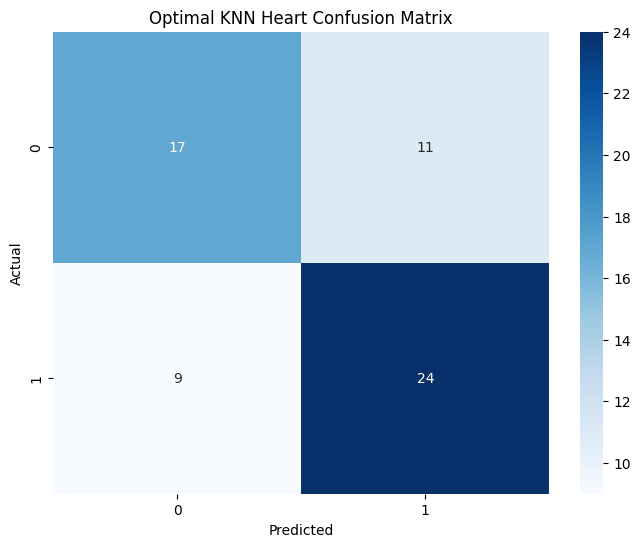

Optimal KNN Heart Confusion Matrix:
 [[17 11]
 [ 9 24]]


In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique class labels for consistent plotting
class_labels_heart = sorted(list(set(y_test_heart).union(set(y_pred_heart_optimal))))

# Generate the confusion matrix
cm_heart_optimal = confusion_matrix(y_test_heart, y_pred_heart_optimal, labels=class_labels_heart)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_heart_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_heart, yticklabels=class_labels_heart)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Optimal KNN Heart Confusion Matrix')
plt.show()

print("Optimal KNN Heart Confusion Matrix:\n", cm_heart_optimal)

In [41]:
from sklearn.metrics import classification_report

# Generate the classification report
report_heart_optimal = classification_report(y_test_heart, y_pred_heart_optimal)

print("Optimal KNN Heart Classification Report:")
print(report_heart_optimal)

Optimal KNN Heart Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61      0.63        28
           1       0.69      0.73      0.71        33

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61

